# Análise exploratória dos Dados

## Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.patches import Circle
import pandas as pd
import seaborn as sns
import sys
import random
import os
import seaborn as sns
import plotly.express as px
import plotly.io as pio
import nbformat
import kaleido

## Primeiras operações com o data set

In [ ]:
""" Importando o dataset"""
df = pd.read_parquet("../data/processed/dataset_labeled.parquet")
df.head(50)

,hash,msg,author,committer,lines_added,lines_deleted,files_modified,is_merge,branches,num_parents,is_main,author_experience,commit_day,commit_hour,subsystems_modified,total_complexity,ddm_unit_size,ddm_unit_count,ddm_unit_interfacing,is_bug
0,a0e7ee9d0d12370e8d2b5ae0a23b6e687e018d85,New repository initialized by cvs2svn.\n\ngit-...,(no author),(no author),0,0,0,False,1,0,True,0,1,21,0,0,NaN,NaN,NaN,False
1,5a2615650e104c0713407637d65ae0ce7c2b257a,Initial revision\n\n\ngit-svn-id: https://svn....,Sam Ruby,Sam Ruby,1910,0,30,False,1,1,True,0,1,21,8,0,NaN,NaN,NaN,True
2,749b4aaf7e922884dba4d01223742f83ecfe57fe,- adding some additional libs that were part o...,Jason van Zyl,Jason van Zyl,196,0,3,False,1,1,True,0,1,16,1,0,NaN,NaN,NaN,False
3,bd3948c539ec1065db8b05b433ea55dbf844ff27,Initial revision\n\n\ngit-svn-id: https://svn....,Jason van Zyl,Jason van Zyl,16175,0,134,False,1,1,True,1,1,16,15,1481,0.543598,0.662019,0.876080,True
4,903b4b0178f8fbe8ce3fde8f80774527592db1ff,- properties for the lucene build\nPR:\nObtain...,Jason van Zyl,Jason van Zyl,38,0,1,False,1,1,True,2,1,16,1,0,NaN,NaN,NaN,True
5,7fb01d68ac7381ff5d28ab2d064d5c88a2aefadc,"- build file for lucene, incorporates ted's wo...",Jason van Zyl,Jason van Zyl,352,46,1,False,1,1,True,3,1,16,1,0,NaN,NaN,NaN,True
6,412a00a07db2b91cfd39d80a18f7c08224a6515c,- adding ignore file\n- removing velocity.log\...,Jason van Zyl,Jason van Zyl,56,57,3,False,1,1,True,4,1,16,1,0,NaN,NaN,NaN,False
7,1a3dd53ada1bd479590459bf7d0d24887f202afa,- a few stray pieces of documentation. ted you...,Jason van Zyl,Jason van Zyl,302,0,2,False,1,1,True,5,1,16,1,0,NaN,NaN,NaN,False
8,4e68f4be90f73dadb0bfcf20e4d0758511d939a9,"- getting the ""demo"" target to work.\n\n the ...",Jason van Zyl,Jason van Zyl,12,6,2,False,1,1,True,6,1,17,1,0,NaN,NaN,NaN,False
9,864293c622721bdc2f290929e005f46b32779599,- fixes required to make the demo build. i mis...,Jason van Zyl,Jason van Zyl,38,31,9,False,1,1,True,7,1,17,3,64,NaN,NaN,NaN,False


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38421 entries, 0 to 38420
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   hash                  38421 non-null  object 
 1   msg                   38421 non-null  object 
 2   author                38421 non-null  object 
 3   committer             38421 non-null  object 
 4   lines_added           38421 non-null  int64  
 5   lines_deleted         38421 non-null  int64  
 6   files_modified        38421 non-null  int64  
 7   is_merge              38421 non-null  bool   
 8   branches              38421 non-null  int64  
 9   num_parents           38421 non-null  int64  
 10  is_main               38421 non-null  bool   
 11  author_experience     38421 non-null  int64  
 12  commit_day            38421 non-null  int64  
 13  commit_hour           38421 non-null  int64  
 14  subsystems_modified   38421 non-null  int64  
 15  total_complexity   

In [14]:
df.shape

(38421, 20)

### Analise das variáveis

#### Hash = Unique

In [4]:
df['hash'].value_counts()

hash
a0e7ee9d0d12370e8d2b5ae0a23b6e687e018d85    1
5a2615650e104c0713407637d65ae0ce7c2b257a    1
749b4aaf7e922884dba4d01223742f83ecfe57fe    1
bd3948c539ec1065db8b05b433ea55dbf844ff27    1
903b4b0178f8fbe8ce3fde8f80774527592db1ff    1
                                           ..
9a7cd0aceb28c16d3f41ba0e975743a6441509b9    1
86d45d708fbeb4a30ece31e928bb6c651596a494    1
fbc74a5aafd0c80494ff69224834a05d0dc2c556    1
46a4fee65580a35a39b1fb4d04a5d87b3ec7d1f2    1
b3f4011292c2e4ffc0e0471e830ccb813c72f44a    1
Name: count, Length: 38421, dtype: int64

#### msg = Mensagens (Texto)

In [3]:
df['msg'].value_counts()

msg
Merge branch 'master' of https://git-wip-us.apache.org/repos/asf/lucene-solr                                                                                                               166
Merge remote-tracking branch 'origin/master'                                                                                                                                                64
Merge remote-tracking branch 'origin/master' into gradle-master                                                                                                                             36
Merge branch 'apache-https-master' into jira/solr-8593                                                                                                                                      29
SOLR-12028: BadApple and AwaitsFix annotations usage                                                                                                                                        24
                                         

#### author = Autor do push (Texto)

In [4]:
df['author'].value_counts()

author
Robert Muir           3916
Michael McCandless    3059
Uwe Schindler         2106
Yonik Seeley          1850
Mark Robert Miller    1782
                      ... 
Arthur Caccavo           1
Eugene Gluzberg          1
YeonghyeonKo             1
Ao Li                    1
Sam Ruby                 1
Name: count, Length: 528, dtype: int64

In [5]:
pio.renderers.default = 'vscode'
hist1 = px.histogram(df, x='author', nbins=60)
hist1.update_layout(width = 800, height = 500, title_text='Contagem')
hist1.update_traces(
    marker_line_width=3,       # espessura da borda em pixels
    marker_line_color='blue'  # cor da borda
)
hist1.show()

#### Commiter = Quem fez o commit (Texto)

In [6]:
df['committer'].value_counts()

committer
Robert Muir           3733
GitHub                3522
Michael McCandless    3032
Uwe Schindler         1990
Yonik Seeley          1849
                      ... 
KoenDG                   1
fabric8-cd               1
Ilan Ginzburg            1
EC2 Default User         1
Zach Chen                1
Name: count, Length: 161, dtype: int64

In [7]:

hist2 = px.histogram(df, x='committer', nbins=20)
hist2.update_layout(width = 800, height = 500, title_text='Commiters')
hist2.update_traces(
    marker_line_width=3,       # espessura da borda em pixels
    marker_line_color='blue'  # cor da borda
)
hist2.show()

#### Lines added = linhas adicionadas (int64)

In [8]:
df['lines_added'].value_counts()

lines_added
1       4183
2       2585
3       1947
0       1849
4       1542
        ... 
4682       1
1942       1
4591       1
1257       1
9430       1
Name: count, Length: 2079, dtype: int64

<Axes: xlabel='lines_added', ylabel='Count'>

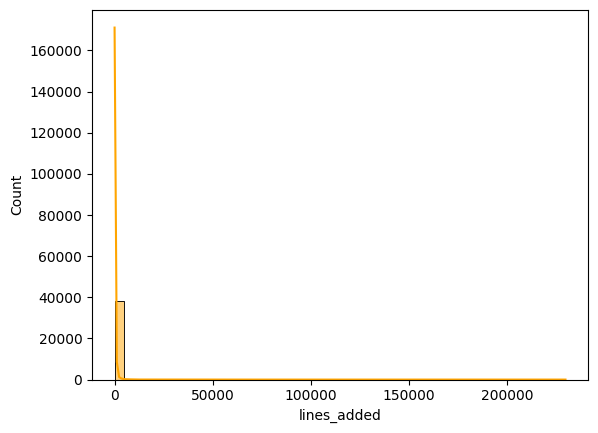

In [9]:
sns.histplot(df,x='lines_added', bins=50, kde=True,color= 'orange')

#### Lines_deleted = Linhas deletadas (int64)

In [15]:
df['lines_deleted'].value_counts()

lines_deleted
1        6343
0        5507
2        3385
3        2124
4        1666
         ... 
11840       1
20233       1
18871       1
41618       1
1766        1
Name: count, Length: 1500, dtype: int64

<Axes: xlabel='lines_deleted', ylabel='Count'>

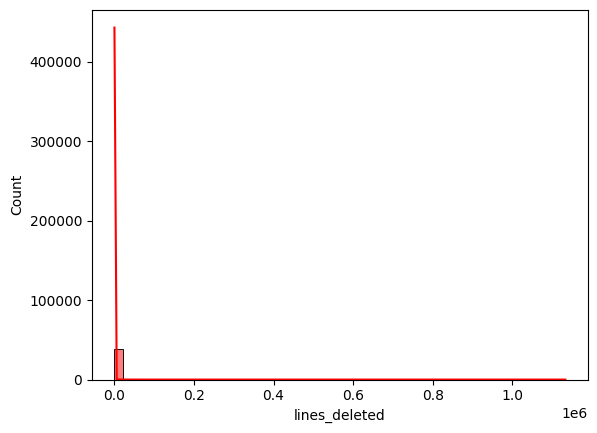

In [16]:
sns.histplot(df,x='lines_deleted', bins=50, kde=True,color= 'red')

#### files_modified = Arquivos modificados (int64)

In [17]:
df['files_modified'].value_counts()

files_modified
1      15628
2       6072
3       4033
4       2369
5       1544
       ...  
544        1
552        1
171        1
165        1
323        1
Name: count, Length: 274, dtype: int64

<Axes: xlabel='lines_deleted', ylabel='Count'>

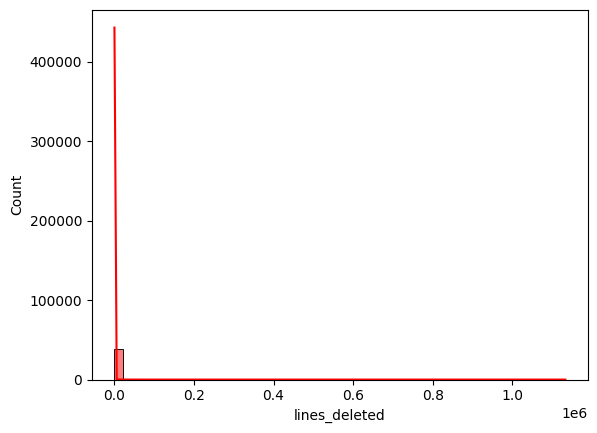

In [18]:
sns.histplot(df,x='lines_deleted', bins=50, kde=True,color= 'red')

#### is_merge = É merge (bool)

In [19]:
df['is_merge'].value_counts()

is_merge
False    37700
True       721
Name: count, dtype: int64

/tmp/ipykernel_1347511/381588995.py:1: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




<Axes: xlabel='is_merge', ylabel='count'>

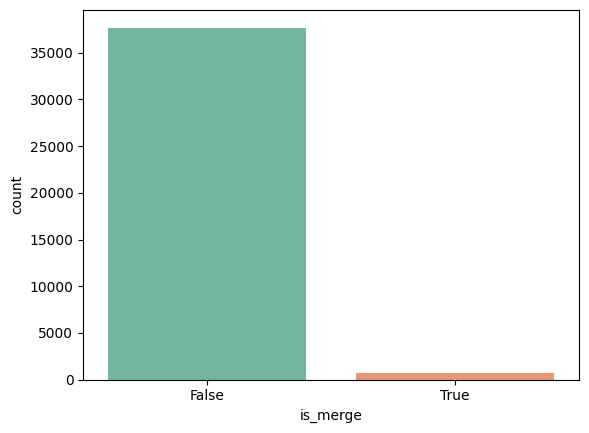

In [20]:
sns.countplot(x='is_merge', data=df, palette='Set2')

#### branches = Numero de  branchs no dado commit extra master (int64)

In [21]:
df['branches'].value_counts()   

branches
1    38421
Name: count, dtype: int64

#### num_parents = numero de commits pai (int64)

In [22]:
df['num_parents'].value_counts()

num_parents
1    37698
2      721
0        2
Name: count, dtype: int64

/tmp/ipykernel_1347511/2978467833.py:1: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




<Axes: xlabel='num_parents', ylabel='count'>

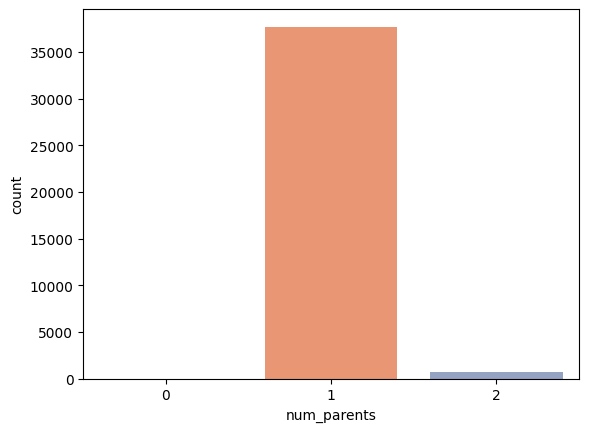

In [25]:
sns.countplot(x='num_parents', data=df, palette='Set2')

#### is_main = o commit foi na main (bool)

In [26]:
df['is_main'].value_counts()

is_main
True    38421
Name: count, dtype: int64

#### author experiencie = experiencia do autor quando ele comitou (int64)

In [ ]:
df['author_experience'].value_counts()

author_experience
0       528
1       278
2       217
3       198
4       183
       ... 
3911      1
3912      1
3913      1
3914      1
3915      1
Name: count, Length: 3916, dtype: int64

<Axes: xlabel='author_experience', ylabel='Count'>

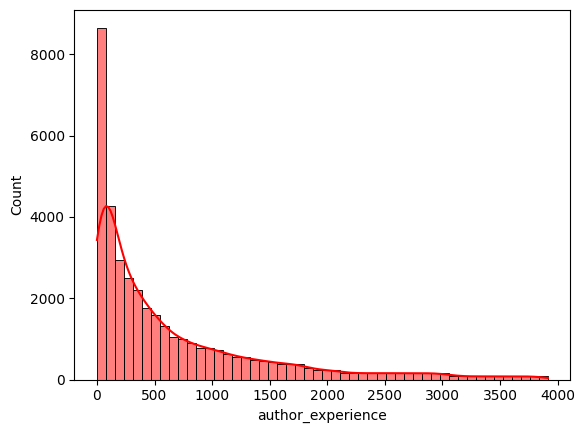

In [28]:
sns.histplot(df,x='author_experience', bins=50, kde=True,color= 'red')

#### Commit day = Dia da semana do commit (int64)

In [29]:
df['commit_day'].value_counts()

commit_day
1    6920
3    6652
2    6580
0    6231
4    5927
6    3067
5    3044
Name: count, dtype: int64

/tmp/ipykernel_1347511/3394119283.py:1: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




<Axes: xlabel='commit_day', ylabel='count'>

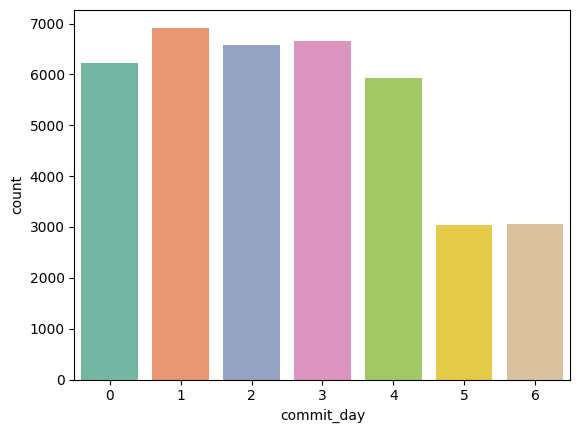

In [32]:
sns.countplot(x='commit_day', data=df, palette='Set2')

#### Commit hour = Hora em que o commit foi realizado (int64)

In [33]:
df['commit_hour'].value_counts()

commit_hour
15    2748
14    2559
16    2497
17    2372
13    2210
18    2209
19    2143
10    2000
12    1988
20    1977
11    1976
21    1919
9     1727
22    1667
23    1310
8     1168
0     1132
1      878
7      756
2      748
5      646
6      631
3      613
4      547
Name: count, dtype: int64

<Axes: xlabel='commit_hour', ylabel='Count'>

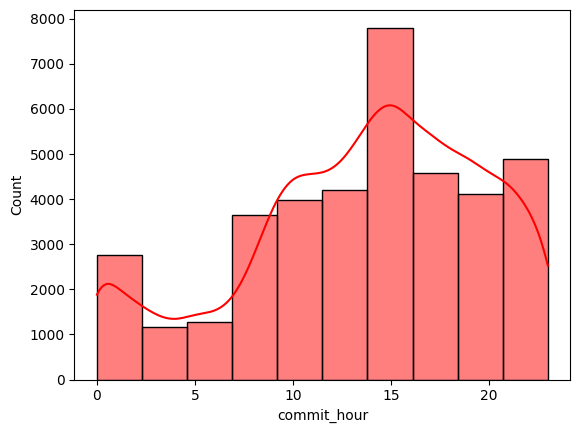

In [35]:
sns.histplot(df,x='commit_hour', bins=10, kde=True,color= 'red')

#### subsystems_modified = subsistemas modificados (int64)

In [36]:
df['subsystems_modified'].value_counts()

subsystems_modified
1      18029
2       6966
3       4789
4       2251
5       1293
       ...  
273        1
80         1
92         1
110        1
77         1
Name: count, Length: 130, dtype: int64

<Axes: xlabel='subsystems_modified', ylabel='Count'>

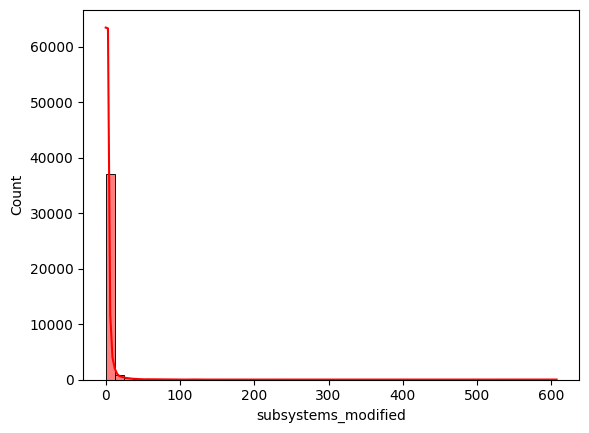

In [37]:
sns.histplot(df,x='subsystems_modified', bins=50, kde=True,color= 'red')

#### total_complexity = Complexidade total (int64)

In [38]:
df['total_complexity'].value_counts()

total_complexity
0        9610
8         267
12        255
38        244
20        232
         ... 
2913        1
1260        1
11859       1
4082        1
1818        1
Name: count, Length: 2273, dtype: int64

<Axes: xlabel='total_complexity', ylabel='Count'>

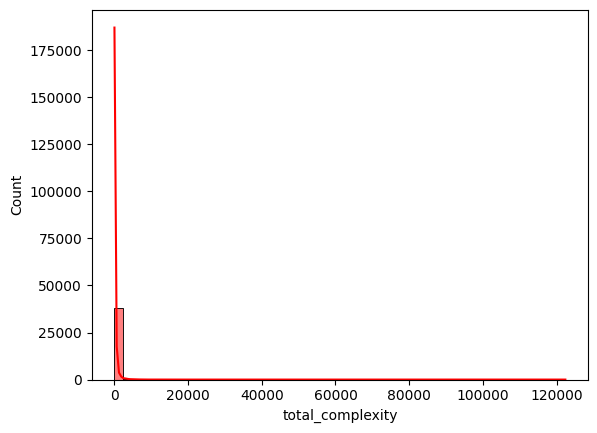

In [39]:
sns.histplot(df,x='total_complexity', bins=50, kde=True,color= 'red')

#### ddm_unit_count (Design and Data Metrics | numero de unidades) (float64)

In [40]:
df['ddm_unit_count'].value_counts

<bound method IndexOpsMixin.value_counts of 0             NaN
1             NaN
2             NaN
3        0.662019
4             NaN
           ...   
38416         NaN
38417         NaN
38418         NaN
38419    0.141844
38420    1.000000
Name: ddm_unit_count, Length: 38421, dtype: float64>

<Axes: xlabel='ddm_unit_count', ylabel='Count'>

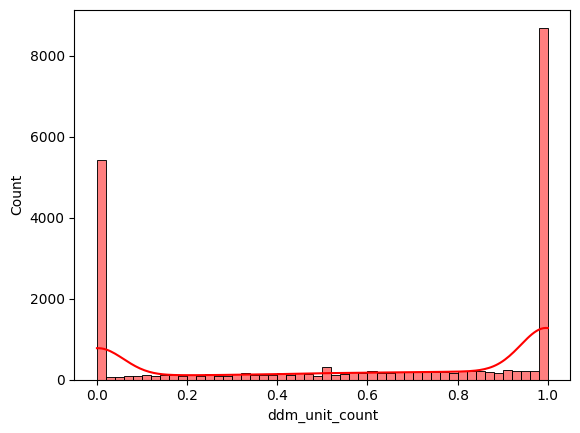

In [41]:
sns.histplot(df,x='ddm_unit_count', bins=50, kde=True,color= 'red')

#### ddm_unit_size

In [42]:
df['ddm_unit_size'].value_counts()

ddm_unit_size
0.000000    7177
1.000000    5610
0.500000     216
0.666667     130
0.333333     110
            ... 
0.738462       1
0.474359       1
0.171598       1
0.695077       1
0.943925       1
Name: count, Length: 3978, dtype: int64

<Axes: xlabel='ddm_unit_size', ylabel='Count'>

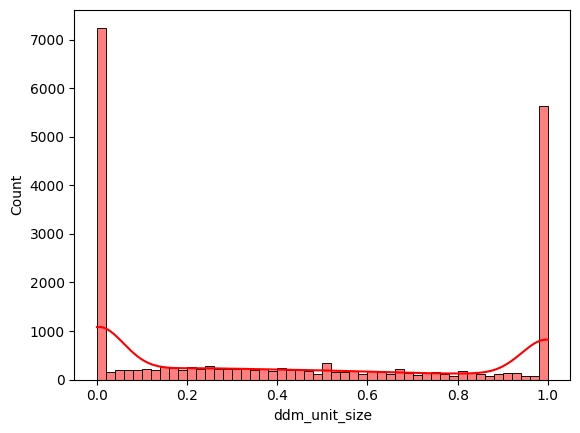

In [43]:
sns.histplot(df,x='ddm_unit_size', bins=50, kde=True,color= 'red')

#### ddm_unit_interfacing

In [44]:
df['ddm_unit_interfacing'].value_counts

<bound method IndexOpsMixin.value_counts of 0             NaN
1             NaN
2             NaN
3        0.876080
4             NaN
           ...   
38416         NaN
38417         NaN
38418         NaN
38419    0.815603
38420    1.000000
Name: ddm_unit_interfacing, Length: 38421, dtype: float64>

<Axes: xlabel='ddm_unit_interfacing', ylabel='Count'>

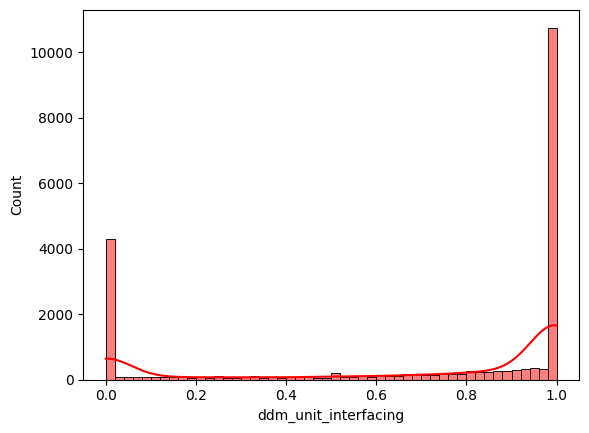

In [45]:
sns.histplot(df,x='ddm_unit_interfacing', bins=50, kde=True,color= 'red')

#### is_bug

In [46]:
df['is_bug'].value_counts()

is_bug
False    25632
True     12789
Name: count, dtype: int64

/tmp/ipykernel_1347511/1968830338.py:1: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




<Axes: xlabel='is_bug', ylabel='count'>

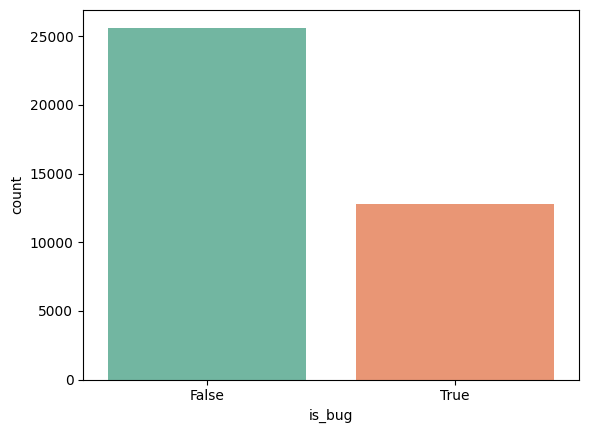

In [47]:
sns.countplot(x='is_bug', data=df, palette='Set2')

In [48]:
px.pie(df, names='is_bug', title='Distribuição de Bugs', color_discrete_sequence=px.colors.qualitative.Set2)